<a href="https://colab.research.google.com/github/07Supreme/AI/blob/main/2438440_SupremeMaharjan_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Choose, Load and Inspect your Data

1) When and Who created the dataset?

Ans: The dataset was created by Pranav Krishna in 2021.

2) How did you get acess to the dataset?

Ans: I got acess to this dataset from the website kaggle.com.

3) List out the attributes (columns) of a dataset.

Ans: The attributes (columns) of a dataset are as follow:
Rank,	Name,	Platform,	Year,	Genre, Publisher, NA_Sales,	EU_Sales,	JP_Sales,	Other_Sales and	Global_Sales.

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:

df = pd.read_csv("/content/drive/MyDrive/Ai/Final Assignment/Regression/vgsales.csv")
df

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [ ]:
df.dtypes

,0
Rank,int64
Name,object
Platform,object
Year,float64
Genre,object
Publisher,object
NA_Sales,float64
EU_Sales,float64
JP_Sales,float64
Other_Sales,float64


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


EXPLORATORY DATA ANALYSIS

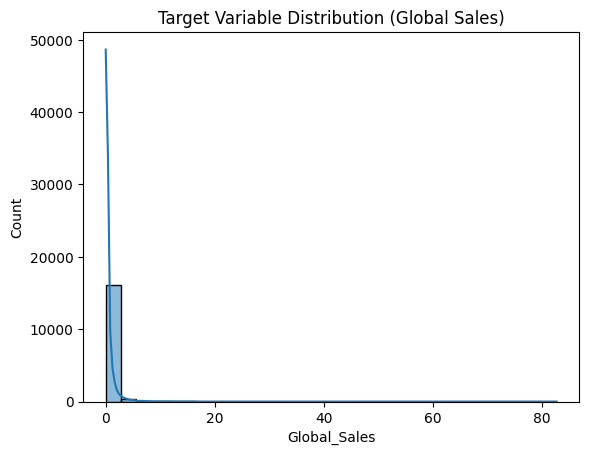

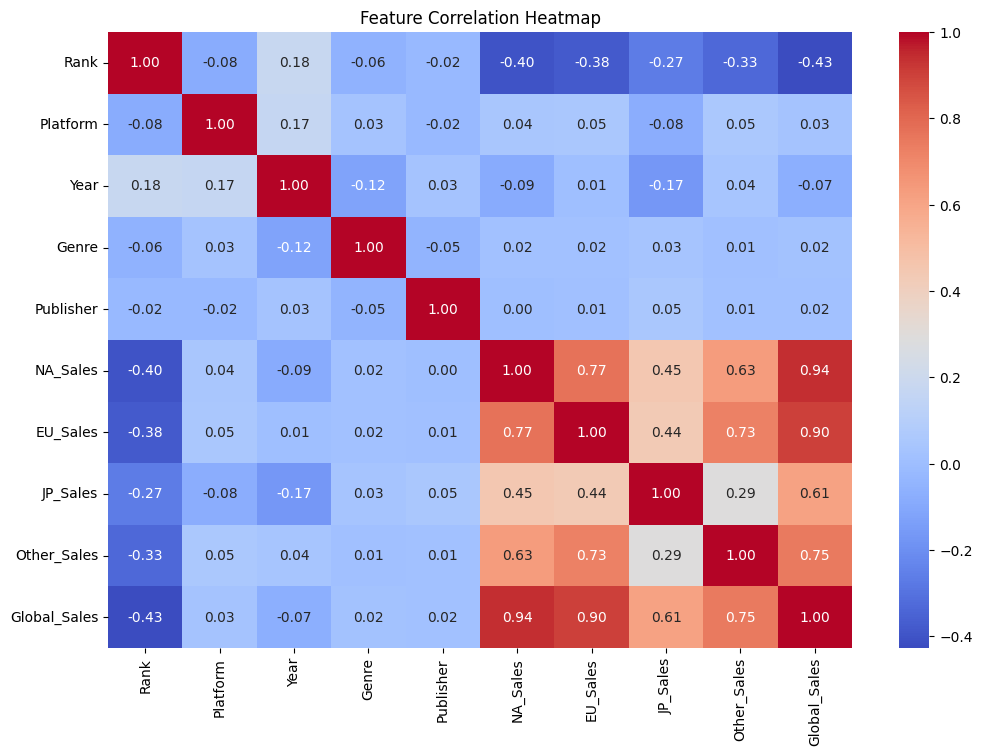

In [ ]:

# Visualizing target distribution (Global Sales)
sns.histplot(df["Global_Sales"], bins=30, kde=True)
plt.title("Target Variable Distribution (Global Sales)")
plt.show()

# Convert categorical columns into numeric using Label Encoding
categorical_columns = ["Platform", "Genre", "Publisher"]
label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Store encoders for future use

# Convert "Year" column to numeric
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna()  # Drop rows where conversion failed

# Selecting numerical columns for correlation heatmap
numeric_df = df.select_dtypes(include=[np.number])

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

This code prepares the vgsales.csv dataset for regression by first visualizing the distribution of Global_Sales using a histogram. It then converts categorical columns (Platform, Genre, Publisher) into numerical values using Label Encoding and ensures the Year column is numeric, dropping any invalid entries. Finally, it selects numerical features and creates a correlation heatmap to analyze relationships between variables, helping identify which features might be most relevant for predicting Global_Sales.

In [ ]:
df.isnull().any()

,0
Rank,False
Name,False
Platform,False
Year,False
Genre,False
Publisher,False
NA_Sales,False
EU_Sales,False
JP_Sales,False
Other_Sales,False


DATA PREPROCESSING


In [ ]:
# Selecting features and target
X = df.drop(columns=["Global_Sales", "Name"]).select_dtypes(include=[np.number]).values
y = df["Global_Sales"].values
if "Rank" in df.columns:
    df.drop(columns=["Rank"], inplace=True)
# Splitting dataset into training and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizing the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

LINEAR REGRESSION FROM SCRATCH

In [ ]:
# Function to compute gradients and update weights
def train_linear_regression(X, y, learning_rate=0.01, epochs=1000):
    m, n = X.shape
    weights = np.zeros(n)
    bias = 0

    for _ in range(epochs):
        predictions = np.dot(X, weights) + bias
        error = predictions - y

        dw = (1 / m) * np.dot(X.T, error)
        db = (1 / m) * np.sum(error)

        weights -= learning_rate * dw
        bias -= learning_rate * db

    return weights, bias

# Train linear regression from scratch
weights_scratch, bias_scratch = train_linear_regression(X_train_scaled, y_train)

# Prediction function
def predict_linear_regression(X, weights, bias):
    return np.dot(X, weights) + bias

# Predictions
y_pred_scratch = predict_linear_regression(X_test_scaled, weights_scratch, bias_scratch)

# Evaluate
mse_scratch = mean_squared_error(y_test, y_pred_scratch)
r2_scratch = r2_score(y_test, y_pred_scratch)

print("\nLinear Regression from Scratch:")
print(f"Mean Squared Error: {mse_scratch:.4f}")
print(f"R-squared: {r2_scratch:.4f}")


Linear Regression from Scratch:
Mean Squared Error: 0.0001
R-squared: 1.0000


TRAIN TWO REGRESSION MODELS

In [ ]:
# Model 1: Linear Regression (Scikit-learn)
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

# Model 2: Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate models
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\nModel Performance Comparison:")
print(f"Linear Regression - MSE: {mse_lr:.4f}, R² Score: {r2_lr:.4f}")
print(f"Random Forest - MSE: {mse_rf:.4f}, R² Score: {r2_rf:.4f}")




Model Performance Comparison:
Linear Regression - MSE: 0.0000, R² Score: 1.0000
Random Forest - MSE: 0.7535, R² Score: 0.8236


HYPERPARAMETER OPTIMIZATION

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import cross_val_score
# Hyperparameter tuning for Ridge and Lasso
alphas = [0.01, 0.1, 1, 10, 100]

best_ridge_alpha = min(alphas, key=lambda alpha: -np.mean(cross_val_score(Ridge(alpha=alpha), X_train, y_train, cv=5, scoring='r2')))
best_lasso_alpha = min(alphas, key=lambda alpha: -np.mean(cross_val_score(Lasso(alpha=alpha), X_train, y_train, cv=5, scoring='r2')))

print(f"Best Ridge Regression Alpha: {best_ridge_alpha}")
print(f"Best Lasso Regression Alpha: {best_lasso_alpha}")

# Hyperparameter tuning for Random Forest
rf_params = {"n_estimators": [50, 100], "max_depth": [5, None]}
rf_cv = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, scoring="r2", cv=5)
rf_cv.fit(X_train_scaled, y_train)

best_rf_params = rf_cv.best_params_
print(f"\nBest Hyperparameters for Random Forest: {best_rf_params}")

Best Ridge Regression Alpha: 0.01
Best Lasso Regression Alpha: 0.01

Best Hyperparameters for Random Forest: {'max_depth': None, 'n_estimators': 100}


FEATURE SELECTION

In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

# Feature Selection for Linear Regression (SelectKBest - Filter Method)
select_k_best = SelectKBest(score_func=f_regression, k=5)
X_train_kbest = select_k_best.fit_transform(X_train_scaled, y_train)
X_test_kbest = select_k_best.transform(X_test_scaled)
selected_features_lr=select_k_best.get_support(indices=True)
selected_features_lin = df.drop(columns=["Global_Sales", "Name"]).select_dtypes(include=[np.number]).columns[selected_features_lr]

print(f"\nSelected Features for the linear Model: {selected_features_lin}")


# Feature selection using Random Forest
selector = SelectFromModel(RandomForestRegressor(n_estimators=100, random_state=42))
selector.fit(X_train_scaled, y_train)

selected_features_rf = selector.get_support(indices=True)
selected_features = np.array(df.drop(columns=["Global_Sales","Name"]).columns)[selected_features_rf]
print(f"\nSelected Features for the random forest Model: {selected_features}")
print(f"\nSelected Features for the Final Model: {selected_features}")



Selected Features for the linear Model: Index(['Year', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales'], dtype='object')

Selected Features for the random forest Model: ['NA_Sales']

Selected Features for the Final Model: ['NA_Sales']


FINAL MODEL



Final Model Performance:
Final Model MSE: 0.7491, R² Score: 0.8247


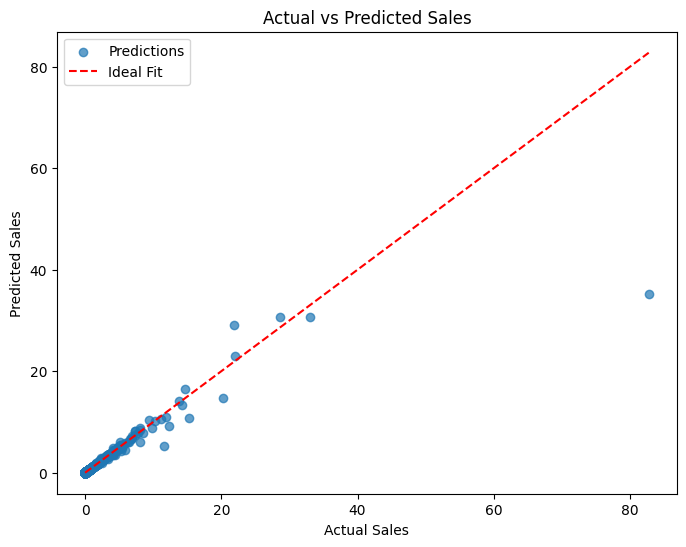

In [ ]:
# Using the best model (Random Forest)

final_model = RandomForestRegressor(**best_rf_params, random_state=42)

# Train final model with selected features
X_train_final = X_train_scaled[:, selected_features_lr]
X_test_final = X_test_scaled[:,selected_features_lr]

final_model.fit(X_train_final, y_train)
y_pred_final = final_model.predict(X_test_final)

# Evaluate final model
mse_final = mean_squared_error(y_test, y_pred_final)
r2_final = r2_score(y_test, y_pred_final)

print("\nFinal Model Performance:")
print(f"Final Model MSE: {mse_final:.4f}, R² Score: {r2_final:.4f}")


# Visualizing the Results
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_final, alpha=0.7, label="Predictions")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color="red", linestyle="--", label="Ideal Fit")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.legend()
plt.show()

This code trains and evaluates the final Random Forest Regressor using the best hyperparameters (best_rf_params) and selected features. It scales the training and test data, fits the model on the training set, and makes predictions on the test set. The model's performance is assessed using Mean Squared Error (MSE) and R² score, which measure prediction accuracy. Finally, it visualizes the results by plotting actual vs. predicted sales, with a red dashed line indicating an ideal perfect prediction. This helps assess how well the model generalizes to unseen data.